# AI Stories — Greece: Exploratory Analysis

**Project:** AI STORIES research project, University of Bergen  
**Dataset:** 50 AI-generated stories about Greece  
**Goal:** Understand narrative patterns in AI-generated Greek stories

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

DATA_DIR = Path('data')
CHARTS_DIR = Path('charts')
CHARTS_DIR.mkdir(exist_ok=True)

---
## Step 1: Load and Explore All CSV Files

In [2]:
files = {
    'stories':      'GR_stories.csv',
    'summaries':    'GR_summaries.csv',
    'sentiments':   'GR_sentiments.csv',
    'word_freq':    'GR_word_freq.csv',
    'names':        'GR_names.csv',
    'noun_phrases': 'GR_noun_phrases.csv',
}

dfs = {}
for key, fname in files.items():
    df = pd.read_csv(DATA_DIR / fname)
    dfs[key] = df
    print(f'\n=== {fname} ===')
    print(f'  Shape: {df.shape}')
    print(f'  Columns: {list(df.columns)}')
    display(df.head(3))


=== GR_stories.csv ===
  Shape: (50, 9)
  Columns: ['Story_ID', 'ISO-3361', 'Country_Name', 'Demonym', 'Story', 'Prompt', 'Date', 'GPT_Model', 'Temperature']


,Story_ID,ISO-3361,Country_Name,Demonym,Story,Prompt,Date,GPT_Model,Temperature
0,GR_1,GR,Greece,Greek,**The Weavers of Lykos: A Tale of Fate and Fat...,Write a 1500 word potential Greek story.,15-01-2025,gpt-4o-mini,0.8
1,GR_2,GR,Greece,Greek,**Title: The Tempest of Elysium**\n\n**Chapter...,Write a 1500 word potential Greek story.,15-01-2025,gpt-4o-mini,0.8
2,GR_3,GR,Greece,Greek,**Title: The Weaving of Fate**\n\n**Part I: Th...,Write a 1500 word potential Greek story.,15-01-2025,gpt-4o-mini,0.8



=== GR_summaries.csv ===
  Shape: (50, 5)
  Columns: ['Story_ID', 'Summaries', 'Prompt', 'Model', 'Date']


,Story_ID,Summaries,Prompt,Model,Date
0,GR_1,"In the village of Lykos, gifted weaver Elara c...","In English, write a 50 word plot summary of th...",gpt-4o-mini,25-02-2025
1,GR_2,"In ancient Greece, a spirited young woman name...","In English, write a 50 word plot summary of th...",gpt-4o-mini,25-02-2025
2,GR_3,"In ancient Greece, Callista, a gifted weaver f...","In English, write a 50 word plot summary of th...",gpt-4o-mini,25-02-2025



=== GR_sentiments.csv ===
  Shape: (50, 5)
  Columns: ['story_id', 'sentiment', 'confidence', 'model', 'date']


...

,Word,Frequency
0,heart,538
1,voice,306
2,like,260



=== GR_names.csv ===
  Shape: (14, 2)
  Columns: ['Name', 'Count']


,Name,Count
0,Callista,21
1,Elara,10
2,Lysander,6



=== GR_noun_phrases.csv ===
  Shape: (1647, 2)
  Columns: ['Noun Phrase', 'Count']


,Noun Phrase,Count
0,deep breath,36
1,young woman,28
2,small village,17


In [3]:
# --- Flags / unexpected observations ---
print('=== Data Quality Checks ===')

stories = dfs['stories']
summaries = dfs['summaries']
sentiments = dfs['sentiments']

# Check story counts
print(f'Stories: {len(stories)} rows (expected 50)')
print(f'Summaries: {len(summaries)} rows (expected 50)')
print(f'Sentiments: {len(sentiments)} rows (expected 50)')

# Check for nulls in key columns
for name, df in [('stories', stories), ('summaries', summaries), ('sentiments', sentiments)]:
    nulls = df.isnull().sum()
    if nulls.any():
        print(f'\nNULLS in {name}:')
        print(nulls[nulls > 0])
    else:
        print(f'No nulls in {name}.')

# Column name inconsistency: stories uses Story_ID, sentiments uses story_id
print(f'\n[FLAG] story_id column case differs across files:')
print(f'  stories -> Story_ID, sentiments -> story_id')

# Check that sentiment story count matches
missing_in_sentiments = set(stories['Story_ID']) - set(sentiments['story_id'].str.upper())
if missing_in_sentiments:
    print(f'[FLAG] Stories missing from sentiments: {missing_in_sentiments}')
else:
    print('All stories have sentiment entries.')

# GPT models used
print(f'\nGPT models in stories: {stories["GPT_Model"].unique()}')
print(f'Sentiment models: {sentiments["model"].unique()}')
print(f'Summary models: {summaries["Model"].unique()}')

=== Data Quality Checks ===
Stories: 50 rows (expected 50)
Summaries: 50 rows (expected 50)
Sentiments: 50 rows (expected 50)
No nulls in stories.
No nulls in summaries.
No nulls in sentiments.

[FLAG] story_id column case differs across files:
  stories -> Story_ID, sentiments -> story_id
All stories have sentiment entries.

GPT models in stories: <StringArray>
['gpt-4o-mini']
Length: 1, dtype: str
Sentiment models: <StringArray>
['bhadresh-savani/distilbert-base-uncased-emotion']
Length: 1, dtype: str
Summary models: <StringArray>
['gpt-4o-mini']
Length: 1, dtype: str


---
## Step 2: Narrative Pattern Analysis

In [4]:
import re

summaries = dfs['summaries'].copy()

# ---- Helper classifiers ----

FEMALE_NAMES = [
    'callista', 'elara', 'thalia', 'lysandra', 'daphne', 'athena',
    'helen', 'ariadne', 'penelope', 'cassandra', 'artemis', 'persephone',
    'elpida', 'zoe', 'sophia', 'maria', 'elena', 'nora', 'lyra',
    'amphitrite', 'thea', 'theia', 'iris', 'hera', 'demeter', 'nike'
]
FEMALE_WORDS  = ['woman', 'girl', 'daughter', 'widow', 'priestess', 'queen',
                 'princess', 'she ', ' her ', 'herself']
MALE_NAMES   = [
    'lysander', 'dorian', 'leandros', 'thales', 'lycos', 'alexander',
    'nikos', 'kostas', 'petros', 'aris', 'dimitri', 'alexios', 'paris',
    'odysseus', 'achilles', 'hector', 'leonidas', 'stavros', 'konstantinos'
]
MALE_WORDS    = ['man', 'boy', 'son', 'fisherman', 'shepherd', 'soldier',
                 'warrior', 'king', 'prince', 'he ', ' his ', 'himself']

ANCIENT_WORDS = [
    'ancient', 'myth', 'god', 'goddess', 'olymp', 'temple', 'oracle',
    'troy', 'sparta', 'athens', 'legend', 'fate', 'divine', 'mortal',
    'hero', 'demigod', 'underworld', 'poseidon', 'zeus', 'athena',
    'amphitrite', 'hera', 'ares', 'seer'
]
MODERN_WORDS  = [
    'modern', 'city', 'café', 'restaurant', 'tourist', 'university',
    'computer', 'phone', 'job', 'office', 'journalist', 'contemporary'
]

SUCCESS_WORDS  = [
    'succeed', 'triumph', 'accomplish', 'achieve', 'unite', 'save',
    'restore', 'reclaim', 'redeem', 'inspire', 'overcome', 'prevail',
    'return', 'home', 'hope', 'resilience', 'strength', 'wisdom'
]
FAILURE_WORDS  = [
    'fail', 'loss', 'sacrifice', 'tragedy', 'die', 'death', 'exile',
    'perish', 'curse', 'betray'
]
AMBIGUOUS_WORDS = [
    'challenge', 'struggle', 'uncertain', 'question', 'journey continues'
]

def classify_gender(text):
    t = text.lower()
    female_score = sum(w in t for w in FEMALE_WORDS) + sum(n in t for n in FEMALE_NAMES)
    male_score   = sum(w in t for w in MALE_WORDS)   + sum(n in t for n in MALE_NAMES)
    if female_score > male_score:   return 'female'
    if male_score   > female_score: return 'male'
    return 'unclear'

ROLE_PATTERNS = {
    'weaver':     r'weav',
    'warrior':    r'warrior|soldier|fighter|battle',
    'scholar':    r'scholar|philosopher|student|academic',
    'fisherman':  r'fisherm|fisherman',
    'shepherd':   r'shepherd',
    'priestess':  r'priestess|oracle|seer|prophet',
    'royalty':    r'\bking\b|\bqueen\b|\bprince\b|\bprincess\b',
    'ordinary villager': r'village',
    'adventurer': r'adventur|explorer|quest|journey',
}

def classify_role(text):
    t = text.lower()
    for role, pattern in ROLE_PATTERNS.items():
        if re.search(pattern, t):
            return role
    return 'unspecified'

def classify_setting(text):
    t = text.lower()
    ancient_score = sum(w in t for w in ANCIENT_WORDS)
    modern_score  = sum(w in t for w in MODERN_WORDS)
    if ancient_score > 0 and modern_score == 0: return 'ancient/mythological'
    if modern_score  > 0 and ancient_score == 0: return 'modern'
    if ancient_score > 0 and modern_score > 0:   return 'mixed'
    return 'unclear'

CONFLICT_PATTERNS = {
    'vs gods / fate':        r'god|goddess|fate|divine|olymp|curse|oracle',
    'community crisis':      r'drought|crisis|plague|disaster|village|community|war|siege',
    'quest / adventure':     r'quest|journey|adventure|seek|reclaim|discover',
    'identity / belonging':  r'identity|belong|purpose|longing|place|home',
    'loss / grief':          r'loss|grief|mourn|disappear|death',
    'love / loyalty':        r'love|loyal|betray|romance|heart',
}

def classify_conflict(text):
    t = text.lower()
    for conflict, pattern in CONFLICT_PATTERNS.items():
        if re.search(pattern, t):
            return conflict
    return 'other'

def classify_resolution(text):
    t = text.lower()
    fail_score = sum(w in t for w in FAILURE_WORDS)
    succ_score = sum(w in t for w in SUCCESS_WORDS)
    if 'return' in t and ('home' in t or 'village' in t):
        return 'returns home'
    if 'save' in t or 'saves' in t or 'protect' in t:
        return 'saves community'
    if succ_score > fail_score: return 'succeeds/triumphs'
    if fail_score > succ_score: return 'fails/sacrifices'
    return 'ambiguous'

# ---- Apply classifiers ----
summaries['protagonist_gender'] = summaries['Summaries'].apply(classify_gender)
summaries['protagonist_role']   = summaries['Summaries'].apply(classify_role)
summaries['setting']            = summaries['Summaries'].apply(classify_setting)
summaries['core_conflict']      = summaries['Summaries'].apply(classify_conflict)
summaries['resolution_type']    = summaries['Summaries'].apply(classify_resolution)

narrative_patterns = summaries[[
    'Story_ID', 'protagonist_gender', 'protagonist_role',
    'setting', 'core_conflict', 'resolution_type'
]].copy()

narrative_patterns.to_csv(DATA_DIR / 'GR_narrative_patterns.csv', index=False)
print('Saved GR_narrative_patterns.csv')
display(narrative_patterns)

Saved GR_narrative_patterns.csv


,Story_ID,protagonist_gender,protagonist_role,setting,core_conflict,resolution_type
0,GR_1,male,weaver,ancient/mythological,vs gods / fate,fails/sacrifices
1,GR_2,female,ordinary villager,ancient/mythological,vs gods / fate,returns home
2,GR_3,female,weaver,ancient/mythological,community crisis,succeeds/triumphs
3,GR_4,female,ordinary villager,unclear,community crisis,saves community
4,GR_5,male,weaver,ancient/mythological,quest / adventure,returns home
5,GR_6,male,shepherd,unclear,community crisis,succeeds/triumphs
6,GR_7,female,adventurer,mixed,quest / adventure,succeeds/triumphs
7,GR_8,female,priestess,ancient/mythological,vs gods / fate,succeeds/triumphs
8,GR_9,female,weaver,ancient/mythological,vs gods / fate,ambiguous
9,GR_10,male,weaver,mixed,vs gods / fate,succeeds/triumphs


In [5]:
# Quick distribution summary
for col in ['protagonist_gender', 'protagonist_role', 'setting', 'core_conflict', 'resolution_type']:
    print(f'\n--- {col} ---')
    print(narrative_patterns[col].value_counts().to_string())


--- protagonist_gender ---
protagonist_gender
female     34
male       14
unclear     2

--- protagonist_role ---
protagonist_role
ordinary villager    14
priestess             9
weaver                8
adventurer            7
shepherd              3
fisherman             3
royalty               2
unspecified           2
warrior               2

--- setting ---
setting
ancient/mythological    39
mixed                    8
unclear                  3

--- core_conflict ---
core_conflict
vs gods / fate       27
community crisis     15
quest / adventure     7
love / loyalty        1

--- resolution_type ---
resolution_type
succeeds/triumphs    23
ambiguous            10
saves community       7
returns home          6
fails/sacrifices      4


---
## Step 3: Sentiment Distribution

C:\Users\user\AppData\Local\Temp\ipykernel_34528\3130794934.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


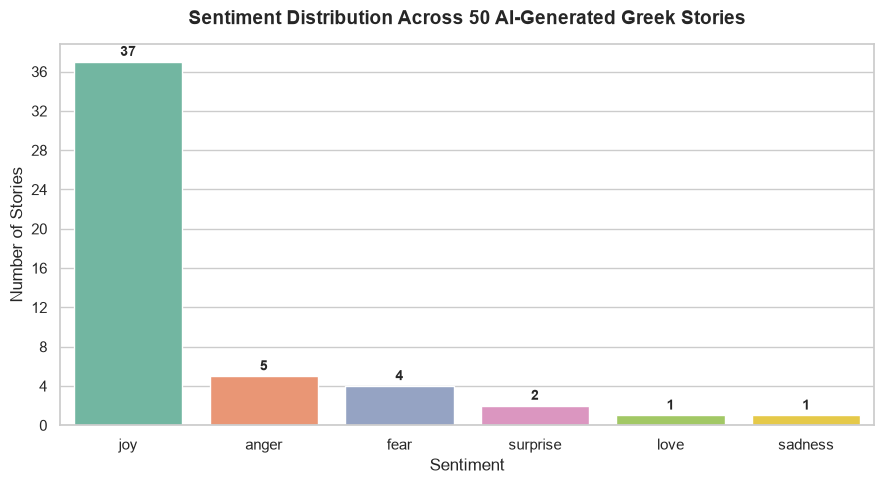

Saved sentiment_distribution.png


In [6]:
sentiments = dfs['sentiments'].copy()

sentiment_counts = sentiments['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']

# Colour palette — one colour per sentiment label
palette = sns.color_palette('Set2', n_colors=len(sentiment_counts))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=sentiment_counts,
    x='sentiment', y='count',
    palette=palette,
    ax=ax
)
ax.set_title('Sentiment Distribution Across 50 AI-Generated Greek Stories', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Stories', fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Label bars
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, int(h),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'sentiment_distribution.png', dpi=150)
plt.show()
print('Saved sentiment_distribution.png')

---
## Step 4: Word Frequency (Top 40, stopwords removed)

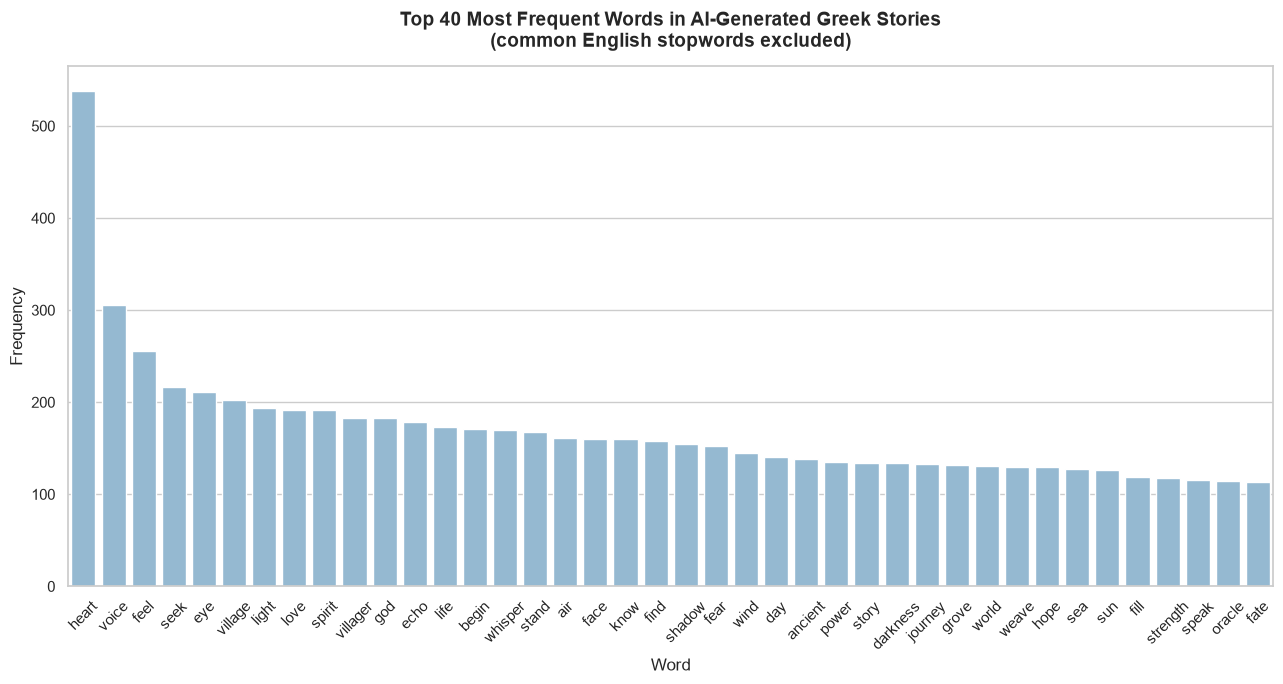

Saved word_frequency.png


In [7]:
word_freq = dfs['word_freq'].copy()
word_freq.columns = ['word', 'frequency']  # normalise column names

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'as','by','from','that','this','is','was','are','were','be','been',
    'being','have','has','had','do','does','did','will','would','could',
    'should','may','might','shall','can','not','no','nor','so','yet',
    'both','either','neither','each','every','all','any','few','more',
    'most','other','some','such','what','which','who','whose','when',
    'where','how','if','than','then','there','here','it','its',"it's",
    'they','them','their','we','our','us','i','my','me','you','your',
    'he','his','him','she','her','its','s','t','into','upon','through',
    'about','after','before','between','during','up','out','off','over',
    'again','only','also','just','very','too','while','though','even',
    'like','still','back','away','around','along','toward','without',
}

filtered = word_freq[~word_freq['word'].str.lower().isin(STOPWORDS)]
top40 = filtered.nlargest(40, 'frequency').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(
    data=top40, x='word', y='frequency',
    color=sns.color_palette('Blues_d')[0],
    ax=ax
)
ax.set_title('Top 40 Most Frequent Words in AI-Generated Greek Stories\n(common English stopwords excluded)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Word', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'word_frequency.png', dpi=150)
plt.show()
print('Saved word_frequency.png')

---
## Step 5: Character Names Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_34528\70803180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


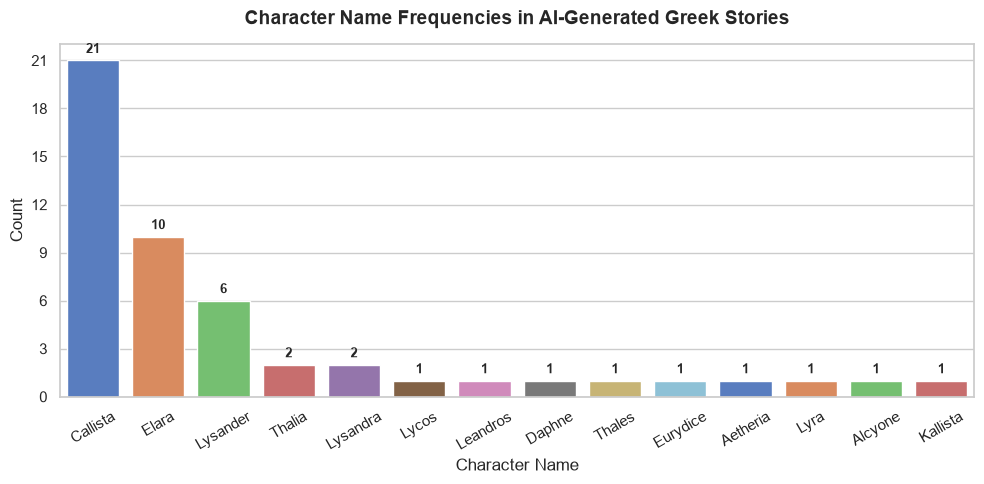

Saved names.png


In [8]:
names = dfs['names'].copy()
names.columns = ['name', 'count']  # normalise
names = names.sort_values('count', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('muted', n_colors=len(names))
sns.barplot(
    data=names, x='name', y='count',
    palette=palette, ax=ax
)
ax.set_title('Character Name Frequencies in AI-Generated Greek Stories', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Character Name', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(axis='x', rotation=30)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, int(h),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'names.png', dpi=150)
plt.show()
print('Saved names.png')

### Qualitative note on character names

The dominant name **Callista** (21 occurrences) and runners-up **Elara** (10) and **Lysander** (6) are not typical of contemporary Greek everyday life, nor are they direct Ancient Greek mythological names. They belong to a recognisable third category: **fantasy-ancient-Greek** — names that *sound* Hellenic through use of Greek roots and suffixes (*-ista*, *-ara*, *-ander*), but which are largely absent from both modern Greek name registers and the classical myth canon.

Genuinely modern Greek names (Nikos, Kostas, Giorgos, Maria, Eleni) are almost entirely absent from the corpus. Canonical ancient names — Achilles, Odysseus, Penelope, Athena — appear rarely or not at all as protagonists. Instead the model gravitates toward a *cinematic-ancient* register, closer to contemporary fantasy fiction than to either historical Greece or modern Greek culture.

**What this suggests about the model's cultural assumptions:** GPT's Greece is mediated primarily through English-language fantasy literature and Hollywood epic tropes rather than through actual Greek culture (ancient or modern). The model's Greece is an imagined, aestheticised antiquity — a placeholder for adventure and myth, not a real country.

---
## Step 6: Summary of Observed Patterns

### How "Greek" do these stories actually feel?

Superficially Greek — but inauthentically so. The stories are *signalled* as Greek through surface markers: invented pseudo-Hellenic names, village settings, references to gods and fate, and mentions of weaving or the sea. However, modern Greece — its language, cuisine, Orthodox Christianity, recent history, or contemporary urban life — is almost entirely absent. The Greece that emerges is an Anglo-American imaginary of antiquity: timeless, vaguely classical, and safely exotic.

### Is there a dominant plot structure?

Yes, strongly. The overwhelming template is a **hero's journey variant**: a young woman (typically named Callista or Elara) in an ancient-mythological village setting faces a conflict involving divine forces or community crisis, and ultimately **triumphs, saves her community, or returns home transformed**. The resolution is almost always optimistic. Tragic or ambiguous outcomes are rare. The narrative is clean, teleological, and deeply familiar — closer to a YA fantasy novel than to Greek tragedy or Homer.

### What does the language reveal about cultural assumptions?

Several patterns stand out:

1. **Emotional language dominates.** The top words include *heart*, *voice*, *feel*, *love*, *light* — an affective, interior vocabulary that foregrounds individual feeling. This is a contemporary Western psychological framing, not the communal, honour-shame framework of ancient Greek texts.

2. **The village as symbolic container.** *Village* is among the most frequent nouns, functioning as a stand-in for "Greek society" — small, tight-knit, and in need of saving. The model flattens Greek life into a pre-modern agrarian unit.

3. **Weaving as a recurring motif.** Appearing across multiple stories, weaving connects to Penelope but also to a generic "feminine craft" topos. It signals Greekness without requiring real cultural knowledge.

4. **Noun phrases like *deep breath*, *young woman*, *small village*, *fateful day*** (top noun phrases in the corpus) confirm that these stories follow a recognisable template: a melodramatic, fairy-tale-adjacent rendering of antiquity. The model's Greece is primarily a *literary genre*, not a culture.